# Retail Sales — Exploratory Data Analysis

This notebook explores a retail transactions dataset to uncover sales trends, customer behaviour patterns, and product/category performance, and closes with actionable business recommendations.

**Dataset:** `Retail_Sales.csv` — 2,000 individual sales transactions across 2022–2023, covering customer demographics, product category, quantity, pricing, cost of goods sold (COGS), and total sale value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('Retail_Sales.csv')
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


## 1. Initial Inspection

Before analysing anything, we check the shape of the dataset, the data types of each column, and where nulls exist.

In [2]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
print("Column data types:")
print(df.dtypes)

Shape: 2000 rows x 11 columns
,
,Column data types:
,transactions_id      int64
,sale_date              str
,sale_time              str
,customer_id          int64
,gender                 str
,age                float64
,category               str
,quantiy            float64
,price_per_unit     float64
,cogs               float64
,total_sale         float64
,dtype: object


In [3]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({'nulls': null_counts, 'pct_missing': null_pct})
null_summary[null_summary['nulls'] > 0]

,nulls,pct_missing
age,10,0.50
quantiy,3,0.15
price_per_unit,3,0.15
cogs,3,0.15
total_sale,3,0.15


**Observation:** The dataset has 2,000 rows and 11 columns. Only 5 columns have missing values (`age`, `quantiy`, `price_per_unit`, `cogs`, `total_sale`), and each has at most 10 missing rows (under 0.5% of the data). This is negligible — we'll drop rows with nulls in the numeric fields used for calculations rather than impute, since the volume lost is trivial.

Note: the source column is spelled `quantiy` (not `quantity`) — this is a typo in the raw file and has been kept as-is to match the data.

In [4]:
df_clean = df.dropna(subset=['quantiy', 'price_per_unit', 'cogs', 'total_sale']).copy()
df_clean['sale_date'] = pd.to_datetime(df_clean['sale_date'])
df_clean['month'] = df_clean['sale_date'].dt.to_period('M').astype(str)
df_clean['quarter'] = df_clean['sale_date'].dt.to_period('Q').astype(str)
df_clean['hour'] = pd.to_datetime(df_clean['sale_time'], format='%H:%M:%S').dt.hour
df_clean['profit'] = df_clean['total_sale'] - df_clean['cogs']

print(f"Rows after dropping nulls in key numeric columns: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

Rows after dropping nulls in key numeric columns: 1997 (dropped 3)


## 2. Descriptive Statistics

Summary statistics for all numerical columns: age, quantity, price per unit, COGS, and total sale value.

In [5]:
numeric_cols = ['age', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']
desc = df_clean[numeric_cols].describe().T
desc['median'] = df_clean[numeric_cols].median()
desc['mode'] = df_clean[numeric_cols].mode().iloc[0]
desc[['mean', 'median', 'mode', 'std', 'min', 'max']].round(2)

,mean,median,mode,std,min,max
age,41.35,42.0,43.0,13.66,18.00,64.0
quantiy,2.51,3.0,4.0,1.13,1.00,4.0
price_per_unit,180.12,50.0,50.0,189.69,25.00,500.0
cogs,95.02,27.5,13.5,121.90,6.25,620.0
total_sale,456.54,150.0,50.0,560.10,25.00,2000.0


**Observation:** The average transaction is worth **~\$457**, but the median is only **\$150** — the mean is pulled up by a smaller number of high-value electronics/clothing purchases (max transaction: \$2,000). Average customer age is ~41, ranging from 18 to 64, so the customer base spans a wide adult age range rather than skewing toward one generation. Average order quantity is ~2.5 units per transaction.

## 3. Time Series Analysis

We look at monthly and quarterly revenue trends to spot seasonality.

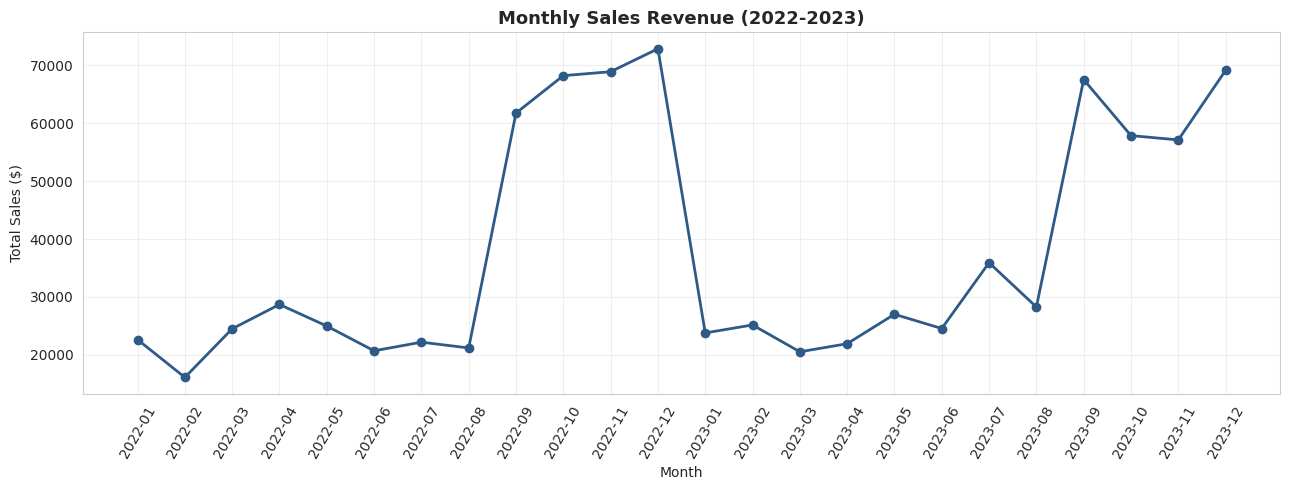

In [6]:
monthly = df_clean.groupby('month')['total_sale'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly.values, marker='o', color='#2E5A88', linewidth=2)
ax.set_title('Monthly Sales Revenue (2022-2023)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=60)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

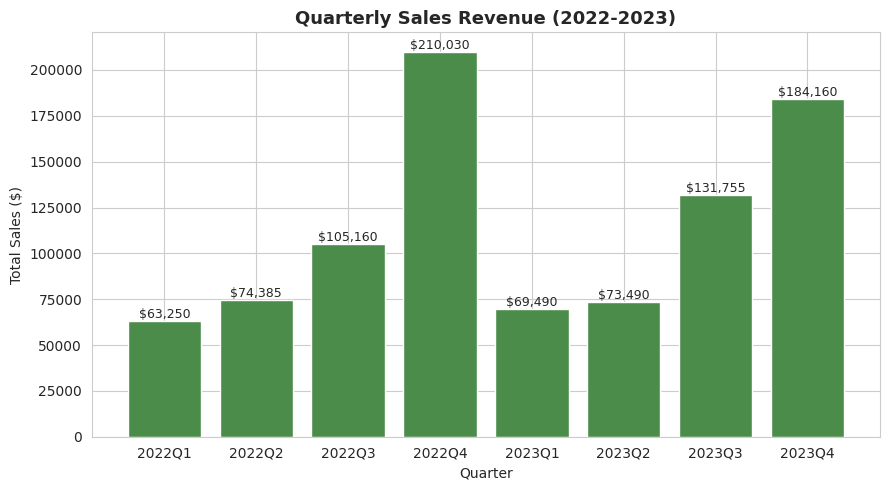

In [7]:
quarterly = df_clean.groupby('quarter')['total_sale'].sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(quarterly.index, quarterly.values, color='#4C8C4A')
ax.set_title('Quarterly Sales Revenue (2022-2023)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales ($)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'${h:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** There is a strong and repeating seasonal pattern: revenue is flat (roughly \$20-25K/month) from January through August, then jumps sharply from September through December in **both** years. Q4 revenue (\$210K in 2022, \$184K in 2023) is roughly **2–3x** Q1/Q2 revenue. This points to a holiday-season effect (Sep–Dec buildup toward year-end shopping) that repeats consistently year over year, making it a reliable pattern to plan inventory and marketing around rather than a one-off spike.

## 4. Customer Demographics

Distribution of customer age groups and gender breakdown.

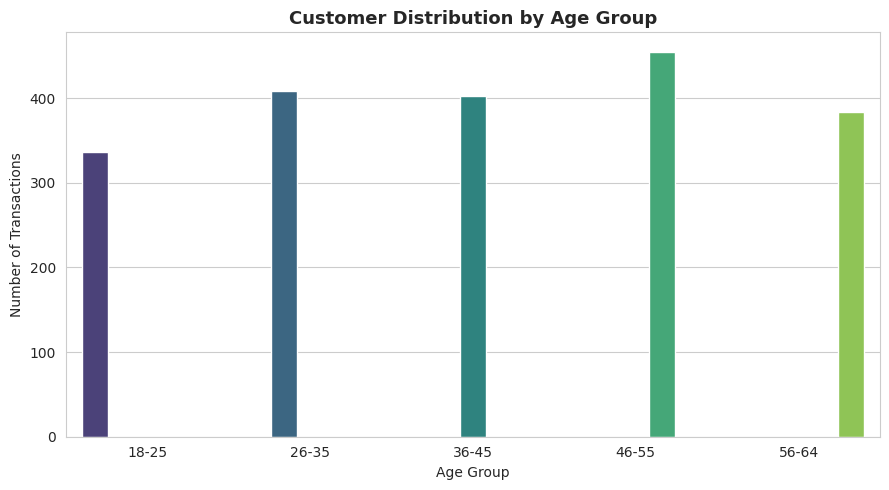

In [8]:
age_bins = [17, 25, 35, 45, 55, 65]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-64']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)

age_group_counts = df_clean['age_group'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, hue=age_group_counts.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Customer Distribution by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

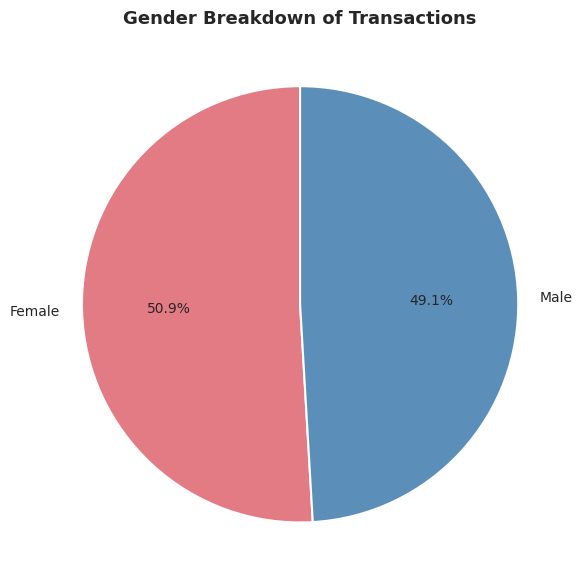

In [9]:
gender_counts = df_clean['gender'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#E37B85', '#5B8FB9']
ax.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Gender Breakdown of Transactions')
plt.tight_layout()
plt.show()

**Observation:** Transactions are almost evenly split between female (~51%) and male (~49%) customers, so there's no strong gender skew to exploit or worry about. Age groups 36-45 and 46-55 are the most active purchasing bands, while 18-25 shows the fewest transactions — suggesting current marketing and product mix may be better tuned to established, higher-income adult shoppers than to younger customers.

## 5. Product & Category Analysis

**Note:** this dataset does not include individual product names — the most granular product-level field available is `category` (Beauty, Clothing, Electronics). So "top 10 best-selling products" is reinterpreted here as **revenue and profitability by category**, which is the finest level of detail the data supports.

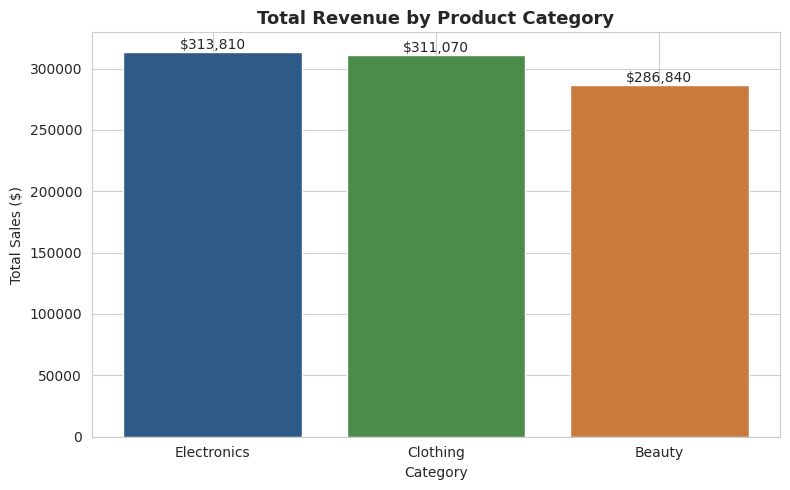

In [10]:
category_revenue = df_clean.groupby('category')['total_sale'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(category_revenue.index, category_revenue.values, color=['#2E5A88', '#4C8C4A', '#C97B3D'])
ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'${h:,.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [11]:
cat_summary = df_clean.groupby('category').agg(
    revenue=('total_sale', 'sum'),
    profit=('profit', 'sum'),
    transactions=('total_sale', 'count'),
    avg_order_value=('total_sale', 'mean')
)
cat_summary['margin_pct'] = (cat_summary['profit'] / cat_summary['revenue'] * 100).round(2)
cat_summary.sort_values('revenue', ascending=False).round(2)

,revenue,profit,transactions,avg_order_value,margin_pct
category,,,,,
Electronics,313810.0,246647.65,684,458.79,78.60
Clothing,311070.0,246679.50,701,443.75,79.30
Beauty,286840.0,228630.15,612,468.69,79.71


**Observation:** Revenue is remarkably evenly split across the three categories — Electronics (\$313.8K), Clothing (\$311.1K), and Beauty (\$286.8K) — no single category dominates. Profit margins are also very close (78.6%–79.7%), with **Beauty carrying the highest margin** despite having the lowest revenue and fewest transactions. This means Beauty products are more profitable per dollar of sale than Electronics or Clothing, even though it moves less volume.

## 6. Correlation Heatmap

Relationships between the numerical variables.

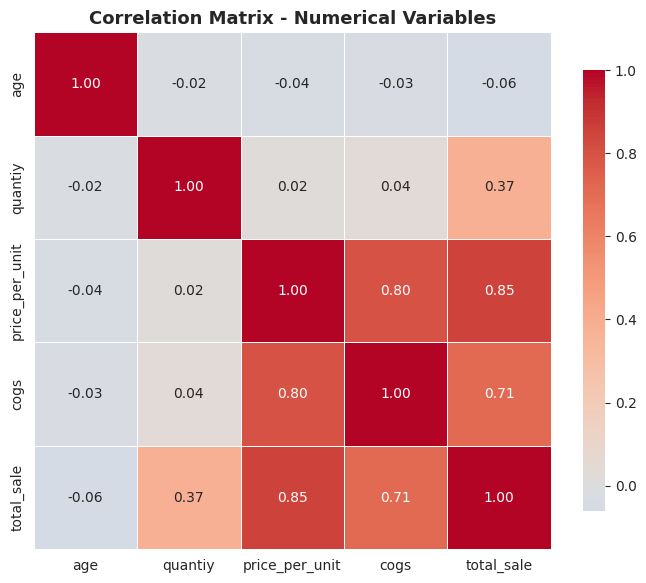

In [12]:
corr = df_clean[['age', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()

**Observation:** `total_sale` is strongly correlated with `price_per_unit` (0.85) and `cogs` (0.71), which makes sense since sale value is largely driven by unit price. `quantiy` has a much weaker correlation with `total_sale` (0.37), meaning higher-value transactions are driven more by buying **pricier items** than by buying **more units**. Notably, `age` shows essentially **no correlation** with any purchasing variable (all near 0) — customer age does not predict spend, quantity, or product price, reinforcing that this business appeals broadly across adult age groups rather than skewing to any one segment.

## 7. Additional Insight — Sales by Hour of Day

A non-obvious pattern worth checking: *when* during the day do sales actually happen?

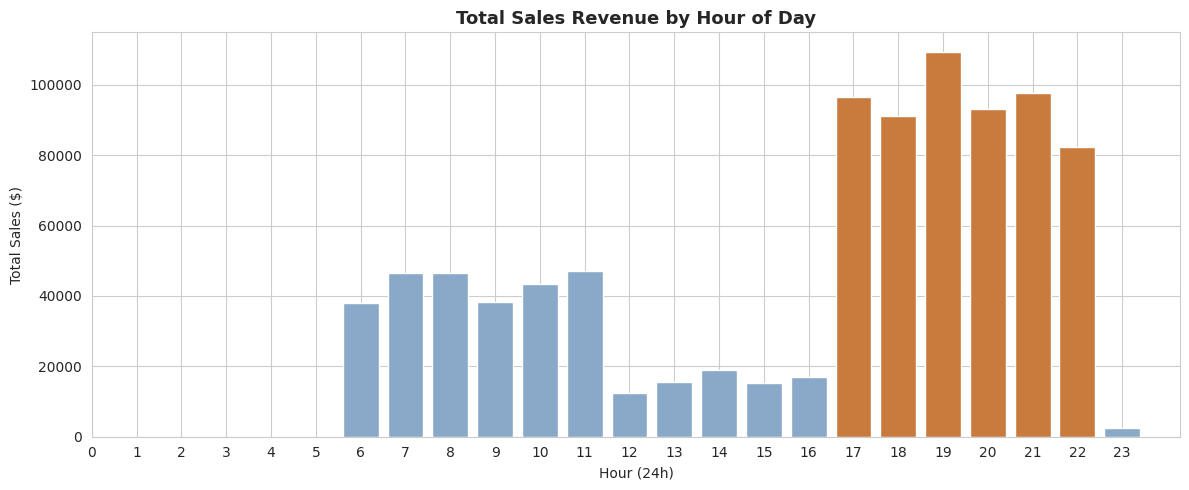

In [13]:
hourly = df_clean.groupby('hour')['total_sale'].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#C97B3D' if h in hourly.nlargest(6).index else '#8AA9C9' for h in hourly.index]
ax.bar(hourly.index, hourly.values, color=colors)
ax.set_title('Total Sales Revenue by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Observation:** This is the most surprising finding in the dataset. Sales revenue is concentrated in the **evening hours (17:00–22:00)**, which together account for a large majority of daily revenue — far outpacing typical daytime "business hours" (9:00–16:00). Hour 19 (7 PM) alone generates the single highest revenue of any hour (~\$109K). This suggests the customer base is shopping after work/school, not during the day — a pattern that has direct implications for staffing, live customer support availability, and the timing of promotional pushes (e.g., flash sales or emails should land in the late afternoon to catch people before this evening peak).

## 8. Conclusion & Business Recommendations

Based on the analysis above, here are three specific, actionable recommendations:

1. **Shift marketing spend and inventory planning toward Q4.** Revenue in Q4 is consistently 2–3x higher than Q1/Q2 in both years of data. Inventory should be built up starting in August, and marketing/promotional budget should be weighted toward September–December rather than spread evenly across the year, to fully capture this reliable seasonal surge.

2. **Protect and grow the Beauty category rather than treating it as the "smallest" line.** Beauty generates the least revenue of the three categories but has the *highest* profit margin (79.7%, vs. 78.6% for Electronics). A modest push to increase Beauty's transaction volume — e.g., bundling Beauty items with Clothing or Electronics purchases, or targeted promotions — would improve overall profitability more than an equivalent push in the lower-margin categories.

3. **Re-time customer engagement to the evening window (5–10 PM).** The overwhelming majority of sales revenue occurs between 17:00 and 22:00, not during standard daytime hours. Promotional emails, flash sales, live chat/support staffing, and social media pushes should be scheduled to land in the late afternoon so they're front-of-mind during this peak window, rather than being spread across a standard 9-to-5 schedule.

**Additional note:** Since age shows no correlation with spending behavior, age-based audience segmentation is unlikely to be a useful targeting lever for this business — category and time-of-day are much stronger signals to design campaigns around.